<h1>Import Libraries</h1>

In [1]:
import os
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


<h1>Settings Config</h1>

In [2]:
DATASET_DIR = "hair_dataset - Copy"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 35

NUM_CLASSES = 6

CLASS_NAMES = [
"breakage", 
"chemical_damage",
"dry",
"healthy", 
"heat_damage", 
"split_ends"
]



<h1>Data Augmentation</h1>

In [3]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

<h1>Load DataSet</h1>

In [4]:


# Load the CSV
df = pd.read_csv(f"{DATASET_DIR}/labels.csv")

# Full image paths
df["filepath"] = DATASET_DIR + "/" + df["filename"]

# Shuffle and split 80/20
df = df.sample(frac=1, random_state=123).reset_index(drop=True)
split = int(len(df) * 0.8)
train_df = df[:split]
val_df = df[split:]

# Dataset builder
def make_dataset(dataframe, augment=False):
    filepaths = dataframe["filepath"].values
    labels = dataframe[CLASS_NAMES].values.astype("float32")

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def load_image(filepath, label):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        return img, label

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        dataset = dataset.map(
        lambda x, y: (tf.squeeze(data_augmentation(tf.expand_dims(x, axis=0), training=True), axis=0), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_df, augment=True)
validation_dataset = make_dataset(val_df, augment=False)
df.head()


,filename,breakage,chemical_damage,dry,healthy,heat_damage,split_ends,filepath
0,chem_dry_break_1.jpeg,1,1,1,0,0,0,hair_dataset - Copy/chem_dry_break_1.jpeg
1,chem_dry_heat_break_2.jpg,1,1,1,0,1,0,hair_dataset - Copy/chem_dry_heat_break_2.jpg
2,aug_1_heat_damage_01.png,0,0,0,0,1,0,hair_dataset - Copy/aug_1_heat_damage_01.png
3,aug_1_breakage_02.png,1,0,0,0,0,0,hair_dataset - Copy/aug_1_breakage_02.png
4,chem_dry_heat_split_break_11.png,1,1,1,0,1,1,hair_dataset - Copy/chem_dry_heat_split_break_...


<h1>Performance Optimization</h1>

In [5]:
from PIL import Image
import os

for fname in os.listdir(DATASET_DIR):
    if fname.lower().endswith('.png'):
        fpath = os.path.join(DATASET_DIR, fname)
        try:
            img = Image.open(fpath)
            if img.format == 'WEBP':  # it's actually a WebP disguised as PNG
                img = img.convert('RGB')
                img.save(fpath, 'PNG')  # now actually saved as PNG
                print(f"Converted: {fname}")
        except Exception as e:
            print(f"Failed: {fname} — {e}")

print("Done")

Done


<h1>Load Pretrained ResNet50</h1>

In [6]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

<h1>Build Model</h1>

In [21]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

#x = data_augmentation(inputs)

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(1024, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

<h1>Compile Model</h1>

In [22]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[2][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │  2,098,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1024)      │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │    524,800 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │    131,328 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 6)         │      1,542 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,351,750 (100.52 MB)

 Trainable params: 2,759,942 (10.53 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

<h1>Callbacks</h1>

In [23]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.2,
    patience=5,
    min_lr = 1e-7
)

In [24]:
df = pd.read_csv(f"{DATASET_DIR}/labels.csv")

before = len(df)
df = df[df["filename"].apply(lambda f: os.path.exists(os.path.join(DATASET_DIR, f)))]
after = len(df)

df.to_csv(f"{DATASET_DIR}/labels.csv", index=False)
print(f"Removed {before - after} missing files. CSV now has {after} rows")

# Show exactly which files are missing
missing = [f for f in df["filename"] if not os.path.exists(os.path.join(DATASET_DIR, f))]
print("Still missing:", missing)

Removed 0 missing files. CSV now has 188 rows
Still missing: []


In [25]:
# Test one batch
for x_batch, y_batch in train_dataset.take(1):
    loss_val = model.evaluate(x_batch, y_batch, verbose=0)
    print("Initial batch loss:", loss_val)

Initial batch loss: [2.8559117317199707, 0.53125]


In [26]:
# Check one batch of data
for x_batch, y_batch in train_dataset.take(1):
    print("Image batch shape:", x_batch.shape)
    print("Image min/max:", x_batch.numpy().min(), x_batch.numpy().max())
    print("\nLabel batch shape:", y_batch.shape)
    print("Label values sample:")
    print(y_batch.numpy()[:5])
    print("\nLabel min/max:", y_batch.numpy().min(), y_batch.numpy().max())
    print("Unique label values:", set(y_batch.numpy().flatten()))

Image batch shape: (32, 224, 224, 3)
Image min/max: 0.0 255.0

Label batch shape: (32, 6)
Label values sample:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 1. 1.]]

Label min/max: 0.0 1.0
Unique label values: {np.float32(0.0), np.float32(1.0)}


<h1>Train Model</h1>

In [27]:
   
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs=EPOCHS,
    callbacks= [early_stop, reduce_lr]
)

Epoch 1/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3800 - loss: 3.0452 - val_accuracy: 0.2632 - val_loss: 2.6847 - learning_rate: 1.0000e-04
Epoch 2/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3400 - loss: 2.8176 - val_accuracy: 0.2105 - val_loss: 2.6126 - learning_rate: 1.0000e-04
Epoch 3/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3200 - loss: 2.7292 - val_accuracy: 0.1842 - val_loss: 2.5830 - learning_rate: 1.0000e-04
Epoch 4/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3067 - loss: 2.6934 - val_accuracy: 0.0789 - val_loss: 2.5656 - learning_rate: 1.0000e-04
Epoch 5/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2533 - loss: 2.6983 - val_accuracy: 0.1579 - val_loss: 2.5501 - learning_rate: 1.0000e-04
Epoch 6/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2533 - loss: 2.6204 - val_accuracy: 0.2105 - val_loss: 2.5341 - learning_rate: 1.0000e-04
Epoch 7/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2400 - loss: 2.6210 - val_

<h1>Optional Fine-Tuning</h1>

In [28]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-7),
    loss="binary_crossentropy",
    metrics=["accuracy"]

)

fine_tune_epochs = 20

history_fine = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = fine_tune_epochs,
    callbacks= [early_stop, reduce_lr]
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.6400 - loss: 2.2753 - val_accuracy: 0.7105 - val_loss: 2.3238 - learning_rate: 1.0000e-07
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.5267 - loss: 2.2939 - val_accuracy: 0.7105 - val_loss: 2.3229 - learning_rate: 1.0000e-07
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6067 - loss: 2.2712 - val_accuracy: 0.7105 - val_loss: 2.3222 - learning_rate: 1.0000e-07
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.5533 - loss: 2.3142 - val_accuracy: 0.7105 - val_loss: 2.3216 - learning_rate: 1.0000e-07
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6067 - loss: 2.2666 - val_accuracy: 0.7105 - val_loss: 2.3206 - learning_rate: 1.0000e-07
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.5133 - loss: 2.3100 - val_accuracy: 0.7105 - val_loss: 2.3201 - learning_rate: 1.0000e-07
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.5333 - loss: 2.3090 - val_

<h1>Save Model</h1>

In [ ]:
model.save("hair_damage_resnet50_multilabel.keras")

print("Model saved successfully.")

<h1>Plot Training Reslts</h1>

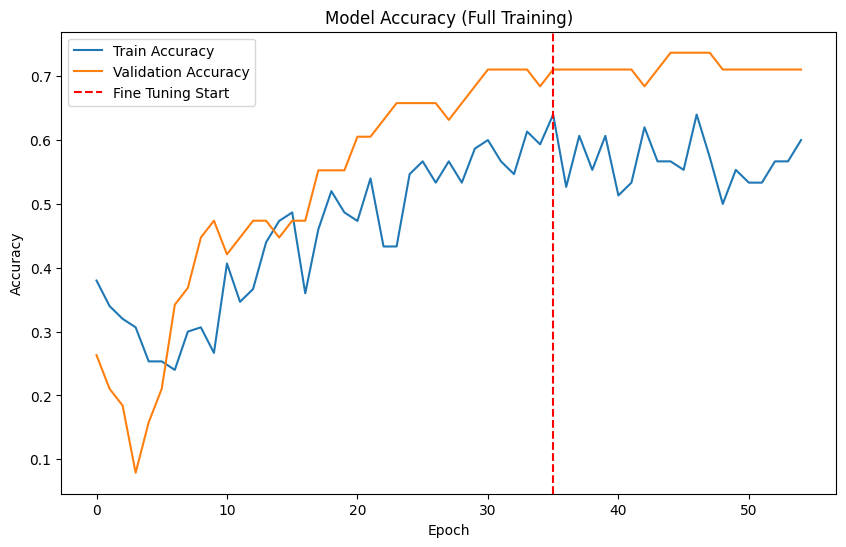

Initial training epochs: 35
Fine tuning epochs: 20
Total epochs: 55
Best validation accuracy: 73.68%


In [30]:
# Combine both phases
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
initial_epochs = len(history.history['accuracy'])

plt.figure(figsize=(10, 6))
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.axvline(x=initial_epochs, color='red', linestyle='--', label='Fine Tuning Start')
plt.title("Model Accuracy (Full Training)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print(f"Initial training epochs: {initial_epochs}")
print(f"Fine tuning epochs: {len(history_fine.history['accuracy'])}")
print(f"Total epochs: {initial_epochs + len(history_fine.history['accuracy'])}")
print(f"Best validation accuracy: {max(val_acc):.2%}")


<h1>Predict on New Image</h1>

In [31]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# ============================================
# Load trained model
# ============================================

model = load_model("hair_damage_resnet50_multilabel.keras")

# ============================================
# Class labels
# ============================================

class_names = [
"breakage", 
"chemical_damage",
"dry",
"healthy", 
"heat_damage", 
"split_ends"
]

# ============================================
# Load image
# ============================================

img_path = "strand.jpg"

img = image.load_img(
    img_path,
    target_size=(224, 224)   # AUTO RESIZE
)

# ============================================
# Convert image to array
# ============================================

img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# ============================================
# Preprocess for ResNet50
# ============================================

img_array = preprocess_input(img_array)

# ============================================
# Predict
# ============================================

predictions = model.predict(img_array)

THRESHOLD = 0.5  # tune this — lower = more labels predicted

predicted_indices = np.where(predictions[0] > THRESHOLD)[0]
predicted_classes = [class_names[i] for i in predicted_indices]

print(f"Predicted conditions: {predicted_classes}")
for i in predicted_indices:
    print(f"  {class_names[i]}: {predictions[0][i]:.2f}")

# ============================================
# Output
# ============================================

#print(f"Prediction: {predicted_class}")

#print(f"Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted conditions: ['breakage', 'dry', 'heat_damage', 'split_ends']
  breakage: 0.96
  dry: 0.96
  heat_damage: 0.65
  split_ends: 0.94


In [32]:
# Check both histories
print("=== Initial Training ===")
print("Epochs:", len(history.history['accuracy']))
print("Final train acc:", history.history['accuracy'][-1])
print("Final val acc:", history.history['val_accuracy'][-1])

print("\n=== Fine Tuning ===")
try:
    print("Epochs:", len(history_fine.history['accuracy']))
    print("Final train acc:", history_fine.history['accuracy'][-1])
    print("Final val acc:", history_fine.history['val_accuracy'][-1])
except NameError:
    print("history_fine does not exist!")
except KeyError:
    print("history_fine exists but has no accuracy key")

=== Initial Training ===
Epochs: 35
Final train acc: 0.5933333039283752
Final val acc: 0.6842105388641357

=== Fine Tuning ===
Epochs: 20
Final train acc: 0.6000000238418579
Final val acc: 0.7105262875556946
